In [169]:
import pandas as dp
import numpy as np
import matplotlib.pyplot as plt


"Você atua como Analista de Dados em uma Insurtech (startup de seguros)
especializada em Seguros de Bens Portáteis (smartphones, notebooks) e Proteção
Pessoal. O Diretor de Riscos e Precificação notou um aumento expressivo no
acionamento de sinistros relacionados a roubos em vias públicas no estado do Rio
de Janeiro e enviou as bases (08.DP.csv e 03.BaseDPEvolucaoMensalCisp.csv)
com o seguinte questionamento:
"Nossas margens de lucro nos seguros de smartphones estão caindo
assustadoramente. Precisamos entender a dinâmica territorial dos crimes de
oportunidade nas ruas. Quero que você cruze os dados das delegacias com o
histórico criminal e me entregue um raio-X estatístico sobre roubos de celular
('roubo_celular') e roubo a pedestres em via publica ('roubo_transeunte').
Precisamos identificar rapidamente quais regiões são verdadeiras zonas vermelhas
(anomalias) para reajustarmos o prêmio do seguro de acordo com o CEP do cliente,
e se há uma correlação direta entre ser roubado na rua e ter o celular levado."

In [170]:
df_mensal = dp.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')
df_dp = dp.read_csv('08.DP.csv', sep=',', encoding='utf-8')


In [171]:

df_merge = df_mensal.merge(df_dp, left_on='cisp', right_on='codDP', how='left')
df_roubo_celular = df_merge[['cisp', 'nome', 'roubo_celular', 'regiao', 'ano']]
df_roubo_transeunte = df_merge[['cisp', 'nome', 'roubo_transeunte', 'regiao', 'ano']]

print(df_roubo_celular.head())
print(df_roubo_transeunte.head())

   cisp                          nome  roubo_celular   regiao   ano
0     1  001ª DP - Praça da República             32  Capital  2003
1     4  004ª DP - Praça da República             14  Capital  2003
2     5           005ª DP - Mem de Sá             34  Capital  2003
3     6         006ª DP - Cidade Nova             20  Capital  2003
4     7        007ª DP - Santa Teresa              1  Capital  2003
   cisp                          nome  roubo_transeunte   regiao   ano
0     1  001ª DP - Praça da República                26  Capital  2003
1     4  004ª DP - Praça da República                25  Capital  2003
2     5           005ª DP - Mem de Sá                26  Capital  2003
3     6         006ª DP - Cidade Nova                14  Capital  2003
4     7        007ª DP - Santa Teresa                 4  Capital  2003


In [172]:
df_roubo_celular = df_merge[['nome', 'roubo_celular']]
df_roubo_celular = df_roubo_celular.groupby('nome').sum().reset_index().sort_values(by='roubo_celular', ascending=False)
df_roubo_celular

,nome,roubo_celular
51,059ª DP - Duque de Caxias,12319
56,064ª DP - São João de Meriti,9414
30,034ª DP - Bangu,8771
25,029ª DP - Madureira,7814
29,033ª DP - Realengo,7175
...,...,...
93,111ª DP - Sumidouro,2
128,155ª DP - São Sebastião do Alto,1
125,152ª DP - Duas Barras,1
130,157ª DP - Trajano de Moraes,1


In [173]:
df_roubo_transeunte = df_merge[['nome', 'roubo_transeunte']]
df_roubo_transeunte = df_roubo_transeunte.groupby('nome').sum().reset_index().sort_values(by='roubo_transeunte', ascending=False)
df_roubo_transeunte

,nome,roubo_transeunte
51,059ª DP - Duque de Caxias,59518
56,064ª DP - São João de Meriti,43262
30,034ª DP - Bangu,42713
64,074ª DP - Alcântara,35892
25,029ª DP - Madureira,31430
...,...,...
115,140ª DP - Natividade,13
129,156ª DP - Santa Maria Madalena,7
76,092ª DP - Rio das Flores,5
128,155ª DP - São Sebastião do Alto,4


Conseguimos observar que há uma correlação entre maior número de roubos de celulares e roubo a transeuntes inicial, mas não necessariamente existe essa correlação quando ambas as tabelas começam a cair. 

In [174]:
df_roubo_celular_array = np.array(df_roubo_celular['roubo_celular'])

amplitude_celular = np.max(df_roubo_celular_array) - np.min(df_roubo_celular_array)

media_roubos_celular = np.mean(df_roubo_celular_array)
mediana_roubos_celular = np.median(df_roubo_celular_array)

q1_celular = np.quantile(df_roubo_celular_array, 0.25)
q2_celular = np.quantile(df_roubo_celular_array, 0.50, method='weibull')
q3_celular = np.quantile(df_roubo_celular_array, 0.75)
iqr_celular = (q3_celular - q1_celular)


limite_superior_celular = q3_celular + (1.5 * iqr_celular)

limite_inferior_celular = q1_celular - (1.5 * iqr_celular)

desvio = np.std(df_roubo_celular_array)
variancia = np.var(df_roubo_celular_array)

distancia_var_media_celular = abs(variancia/media_roubos_celular**2)

cv_celular = desvio/media_roubos_celular

assimetria_celular = df_roubo_celular['roubo_celular'].skew()
kurt_celular = df_roubo_celular['roubo_celular'].kurtosis()
delta_celular = media_roubos_celular - mediana_roubos_celular

In [175]:
df_roubo_transeunte_array = np.array(df_roubo_transeunte['roubo_transeunte'])

amplitude_transeunte = np.max(df_roubo_transeunte_array) - np.min(df_roubo_transeunte_array)

media_roubos_transeunte = np.mean(df_roubo_transeunte_array)
mediana_roubos_transeunte = np.median(df_roubo_transeunte_array)

q1_transeunte = np.quantile(df_roubo_transeunte_array, 0.25)
q2_transeunte = np.quantile(df_roubo_transeunte_array, 0.50, method='weibull')
q3_transeunte = np.quantile(df_roubo_transeunte_array, 0.75)
iqr_transeunte = (q3_transeunte - q1_transeunte)


limite_superior_transeunte = q3_transeunte + (1.5 * iqr_transeunte)
limite_inferior_transeunte = q1_transeunte - (1.5 * iqr_transeunte)

desvio = np.std(df_roubo_transeunte_array)
variancia = np.var(df_roubo_transeunte_array)

distancia_var_media_transeunte = abs(variancia/media_roubos_transeunte**2)

cv_transeunte = desvio/media_roubos_transeunte

assimetria_transeunte = df_roubo_transeunte['roubo_transeunte'].skew()
kurt_transeunte = df_roubo_transeunte['roubo_transeunte'].kurtosis()
delta_transeunte = media_roubos_transeunte - mediana_roubos_transeunte


In [176]:
print(f'Média celular: {media_roubos_celular}')
print(f'Média transeunte: {media_roubos_transeunte}')
print(f'Amplitude celular: {amplitude_celular}')
print(f'Amplitude transeunte: {amplitude_transeunte}')
print(f'Mediana celular: {mediana_roubos_celular}')
print(f'Mediana transeunte: {mediana_roubos_transeunte}')
print(f'Min celular: {np.min(df_roubo_celular_array)}')
print(f'Min transeunte: {np.min(df_roubo_transeunte_array)}')
print(f'Max celular: {np.max(df_roubo_celular_array)}')
print(f'Max transeunte: {np.max(df_roubo_transeunte_array)}')
print(f'Q1 celular: {q1_celular}')
print(f'Q1 transeunte: {q1_transeunte}')
print(f'Q2 celular: {q2_celular}')
print(f'Q2 transeunte: {q2_transeunte}')
print(f'Q3 celular: {q3_celular}')
print(f'Q3 transeunte: {q3_transeunte}')
print(f'Limite Inferior celular: {limite_inferior_celular}')
print(f'Limite Inferior transeunte: {limite_inferior_transeunte}')
print(f'Limite Superior celular: {limite_superior_celular}')
print(f'Limite Superior transeunte: {limite_superior_transeunte}')
print(f'Distância Variância/Média celular: {distancia_var_media_celular}')
print(f'Distância Variância/Média transeunte: {distancia_var_media_transeunte}')
print(f'Coeficiente de Variação celular: {cv_celular}')
print(f'Coeficiente de Variação transeunte: {cv_transeunte}')
print(f'Assimetria celular: {assimetria_celular}')
print(f'Assimetria transeunte: {assimetria_transeunte}')


Média celular: 2026.4087591240875
Média transeunte: 8886.058394160584
Amplitude celular: 12319
Amplitude transeunte: 59515
Mediana celular: 729.0
Mediana transeunte: 3853.0
Min celular: 0
Min transeunte: 3
Max celular: 12319
Max transeunte: 59518
Q1 celular: 47.0
Q1 transeunte: 185.0
Q2 celular: 729.0
Q2 transeunte: 3853.0
Q3 celular: 3767.0
Q3 transeunte: 16159.0
Limite Inferior celular: -5533.0
Limite Inferior transeunte: -23776.0
Limite Superior celular: 9347.0
Limite Superior transeunte: 40120.0
Distância Variância/Média celular: 1.4854158753528774
Distância Variância/Média transeunte: 1.5288011477688472
Coeficiente de Variação celular: 1.2187763844745587
Coeficiente de Variação transeunte: 1.2364469854259208
Assimetria celular: 1.333867329228543
Assimetria transeunte: 1.557684602989991


In [177]:
print(f'Curtose celular: {kurt_celular}')
print(f'Curtose transeunte: {kurt_transeunte}')
print(f'Delta (Média - Mediana) celular: {delta_celular}')
print(f'Delta (Média - Mediana) transeunte: {delta_transeunte}')

Curtose celular: 1.634749320732375
Curtose transeunte: 3.019328764463043
Delta (Média - Mediana) celular: 1297.4087591240875
Delta (Média - Mediana) transeunte: 5033.058394160584


A média é maior que a mediana, e a assimetria é positiva, ou seja, significa que: maioria dos meses tem níveis moderados de crime, mas meses extremamente violentos acabam inflando as estatísticas. Para o negócio, isso significa que o risco não é constante e pode aumentar significativamente em determinados períodos.

In [178]:
df_rouboCelular_outliers_inferiores = df_roubo_celular[df_roubo_celular['roubo_celular'] < limite_inferior_celular]
df_rouboCelular_outliers_superiores = df_roubo_celular[df_roubo_celular['roubo_celular'] > limite_superior_celular]
df_rouboTranseunte_outliers_inferiores = df_roubo_transeunte[df_roubo_transeunte['roubo_transeunte'] < limite_inferior_transeunte]
df_rouboTranseunte_outliers_superiores = df_roubo_transeunte[df_roubo_transeunte['roubo_transeunte'] > limite_superior_transeunte]

if df_rouboCelular_outliers_inferiores.empty:
    print('Não há outliers inferiores para roubo de celular.')
else:
    print(df_rouboCelular_outliers_inferiores.sort_values(by='roubo_celular', ascending=True))

if df_rouboCelular_outliers_superiores.empty:
    print('Não há outliers superiores para roubo de celular.')
else:
    print(df_rouboCelular_outliers_superiores.sort_values(by='roubo_celular', ascending=False))

dp_mais_outliers = df_rouboCelular_outliers_superiores.groupby('nome').size().reset_index(name='Quantidade de Outliers')
dp_mais_outliers = dp_mais_outliers.sort_values(by='Quantidade de Outliers', ascending=False)

print('\nDelegacias com maior número de meses outliers:')
print(dp_mais_outliers)



Não há outliers inferiores para roubo de celular.
                            nome  roubo_celular
51     059ª DP - Duque de Caxias          12319
56  064ª DP - São João de Meriti           9414

Delegacias com maior número de meses outliers:
                           nome  Quantidade de Outliers
0     059ª DP - Duque de Caxias                       1
1  064ª DP - São João de Meriti                       1


In [179]:
if df_rouboTranseunte_outliers_inferiores.empty:
    print('Não há outliers inferiores para roubo de transeunte.')
else:
    print(df_rouboTranseunte_outliers_inferiores.sort_values(by='roubo_transeunte', ascending=True))

if df_rouboTranseunte_outliers_superiores.empty:
    print('Não há outliers superiores para roubo de transeunte.')
else:
    print(df_rouboTranseunte_outliers_superiores.sort_values(by='roubo_transeunte', ascending=False))

Não há outliers inferiores para roubo de transeunte.
                            nome  roubo_transeunte
51     059ª DP - Duque de Caxias             59518
56  064ª DP - São João de Meriti             43262
30               034ª DP - Bangu             42713


C:\Users\martins.ryan\AppData\Local\Temp\ipykernel_28684\363136486.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


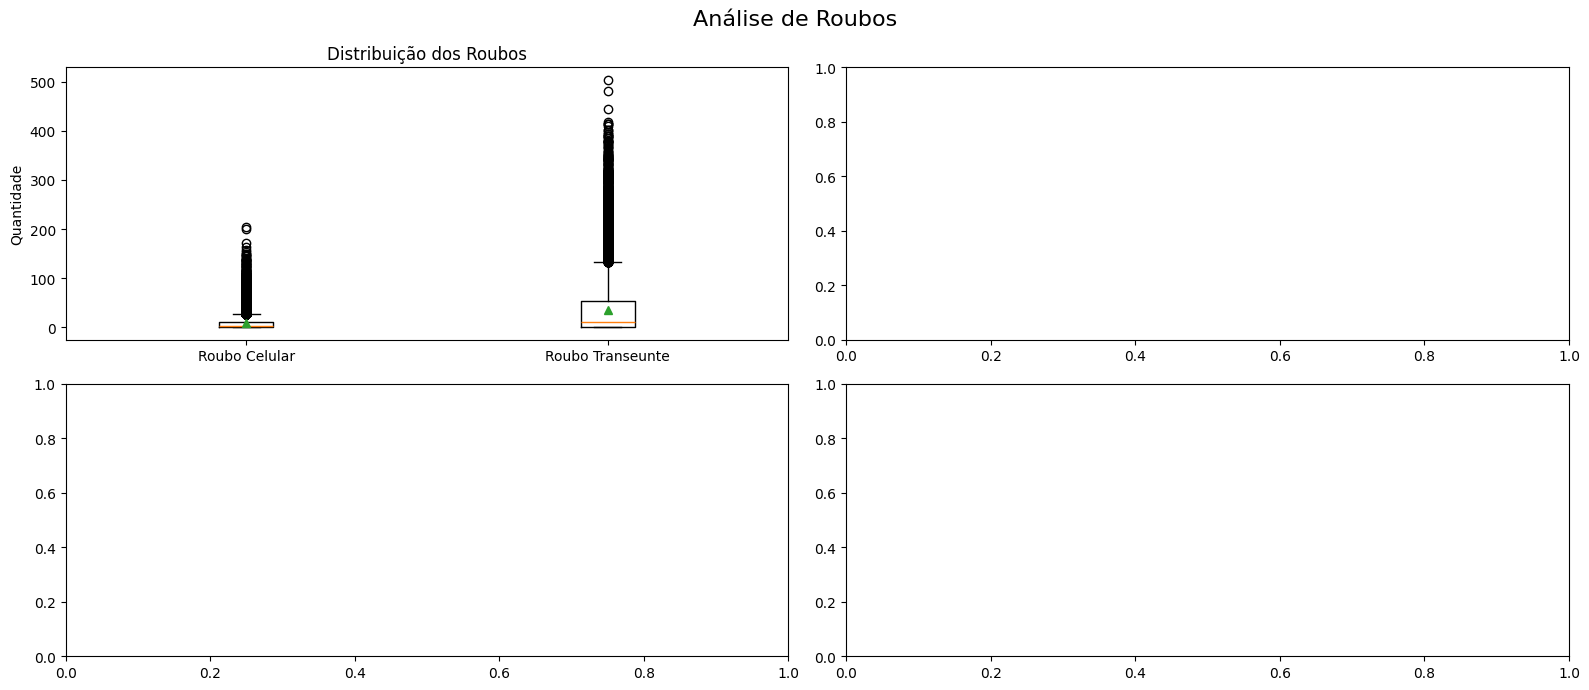

In [190]:
try:
    plt.subplots(2, 2, figsize=(16, 7))
    plt.suptitle('Análise de Roubos', fontsize=16)

    plt.subplot(2, 2, 1)
    plt.boxplot(
        [df_merge['roubo_celular'], df_merge['roubo_transeunte']],
        labels=['Roubo Celular', 'Roubo Transeunte'],
        showmeans=True,
        showfliers=True
    )

    plt.title('Distribuição dos Roubos')
    plt.ylabel('Quantidade')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Erro na visualização de dados: {e}')

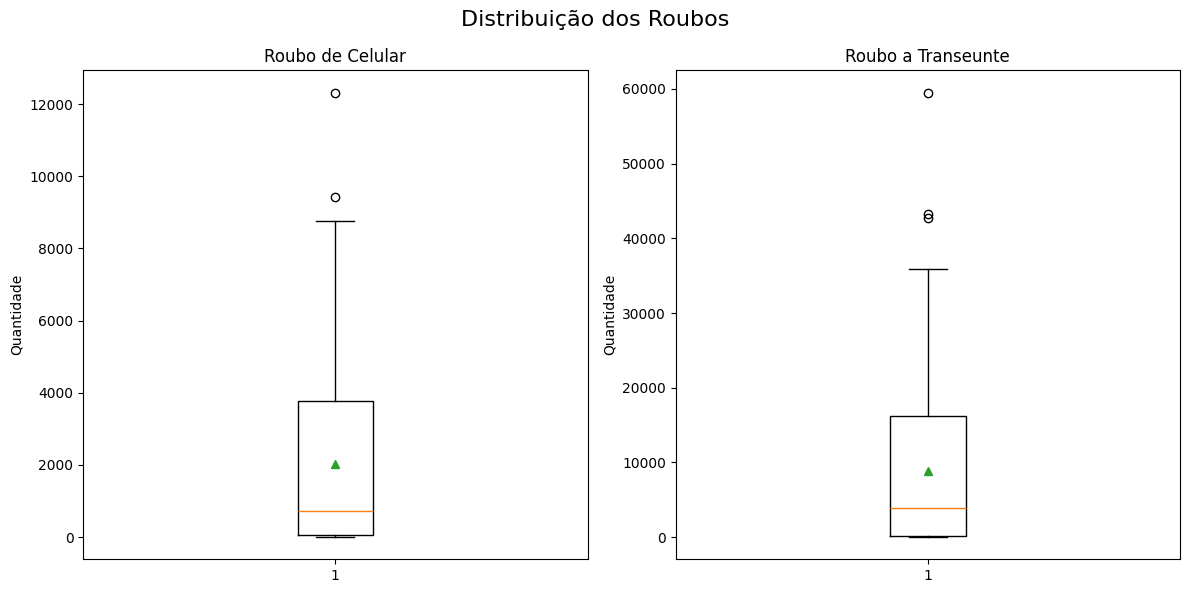

In [189]:
try:
    plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle('Distribuição dos Roubos', fontsize=16)

    plt.subplot(1, 2, 1)
    plt.boxplot(df_roubo_celular['roubo_celular'], showmeans=True, showfliers=True)
    plt.title('Roubo de Celular')
    plt.ylabel('Quantidade')

    plt.subplot(1, 2, 2)
    plt.boxplot(df_roubo_transeunte['roubo_transeunte'], showmeans=True, showfliers=True)
    plt.title('Roubo a Transeunte')
    plt.ylabel('Quantidade')

    plt.tight_layout()
    plt.show()

    
except Exception as e:
    print(f'Erro na visualização de dados: {e}')

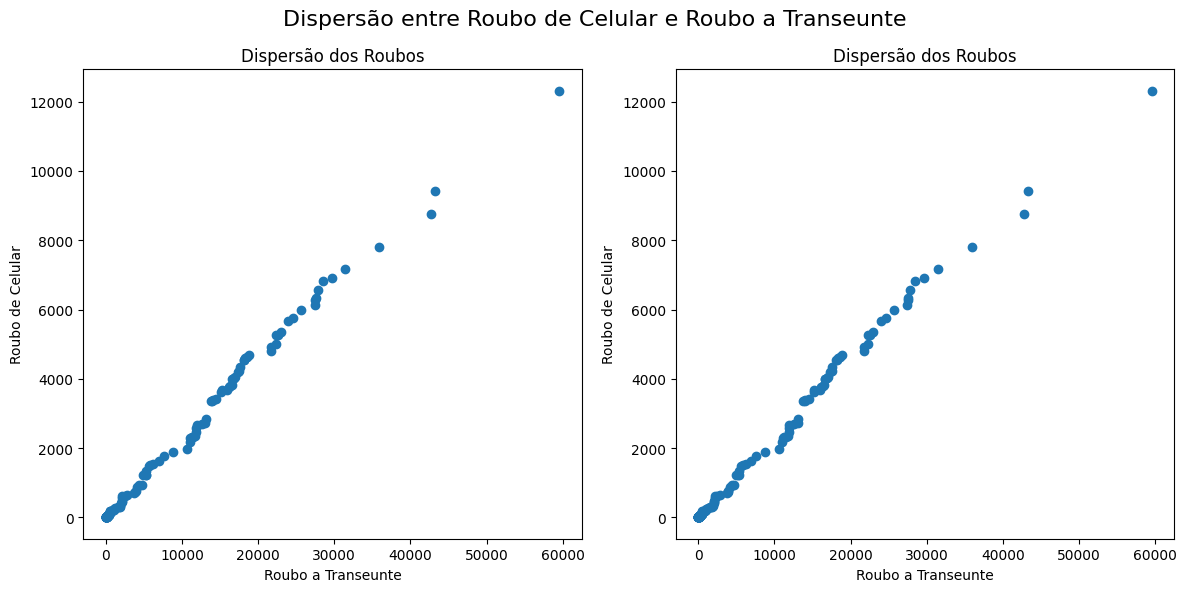

In [188]:
try:
    plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle('Dispersão entre Roubo de Celular e Roubo a Transeunte', fontsize=16)

    plt.subplot(1, 2, 1)
    plt.scatter(df_roubo_transeunte['roubo_transeunte'], df_roubo_celular['roubo_celular'])
    plt.title('Dispersão dos Roubos')
    plt.xlabel('Roubo a Transeunte')
    plt.ylabel('Roubo de Celular')

    plt.subplot(1, 2, 2)
    plt.scatter(df_roubo_transeunte['roubo_transeunte'], df_roubo_celular['roubo_celular'],)
    plt.title('Dispersão dos Roubos')
    plt.xlabel('Roubo a Transeunte')
    plt.ylabel('Roubo de Celular')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Erro na visualização de dados: {e}')

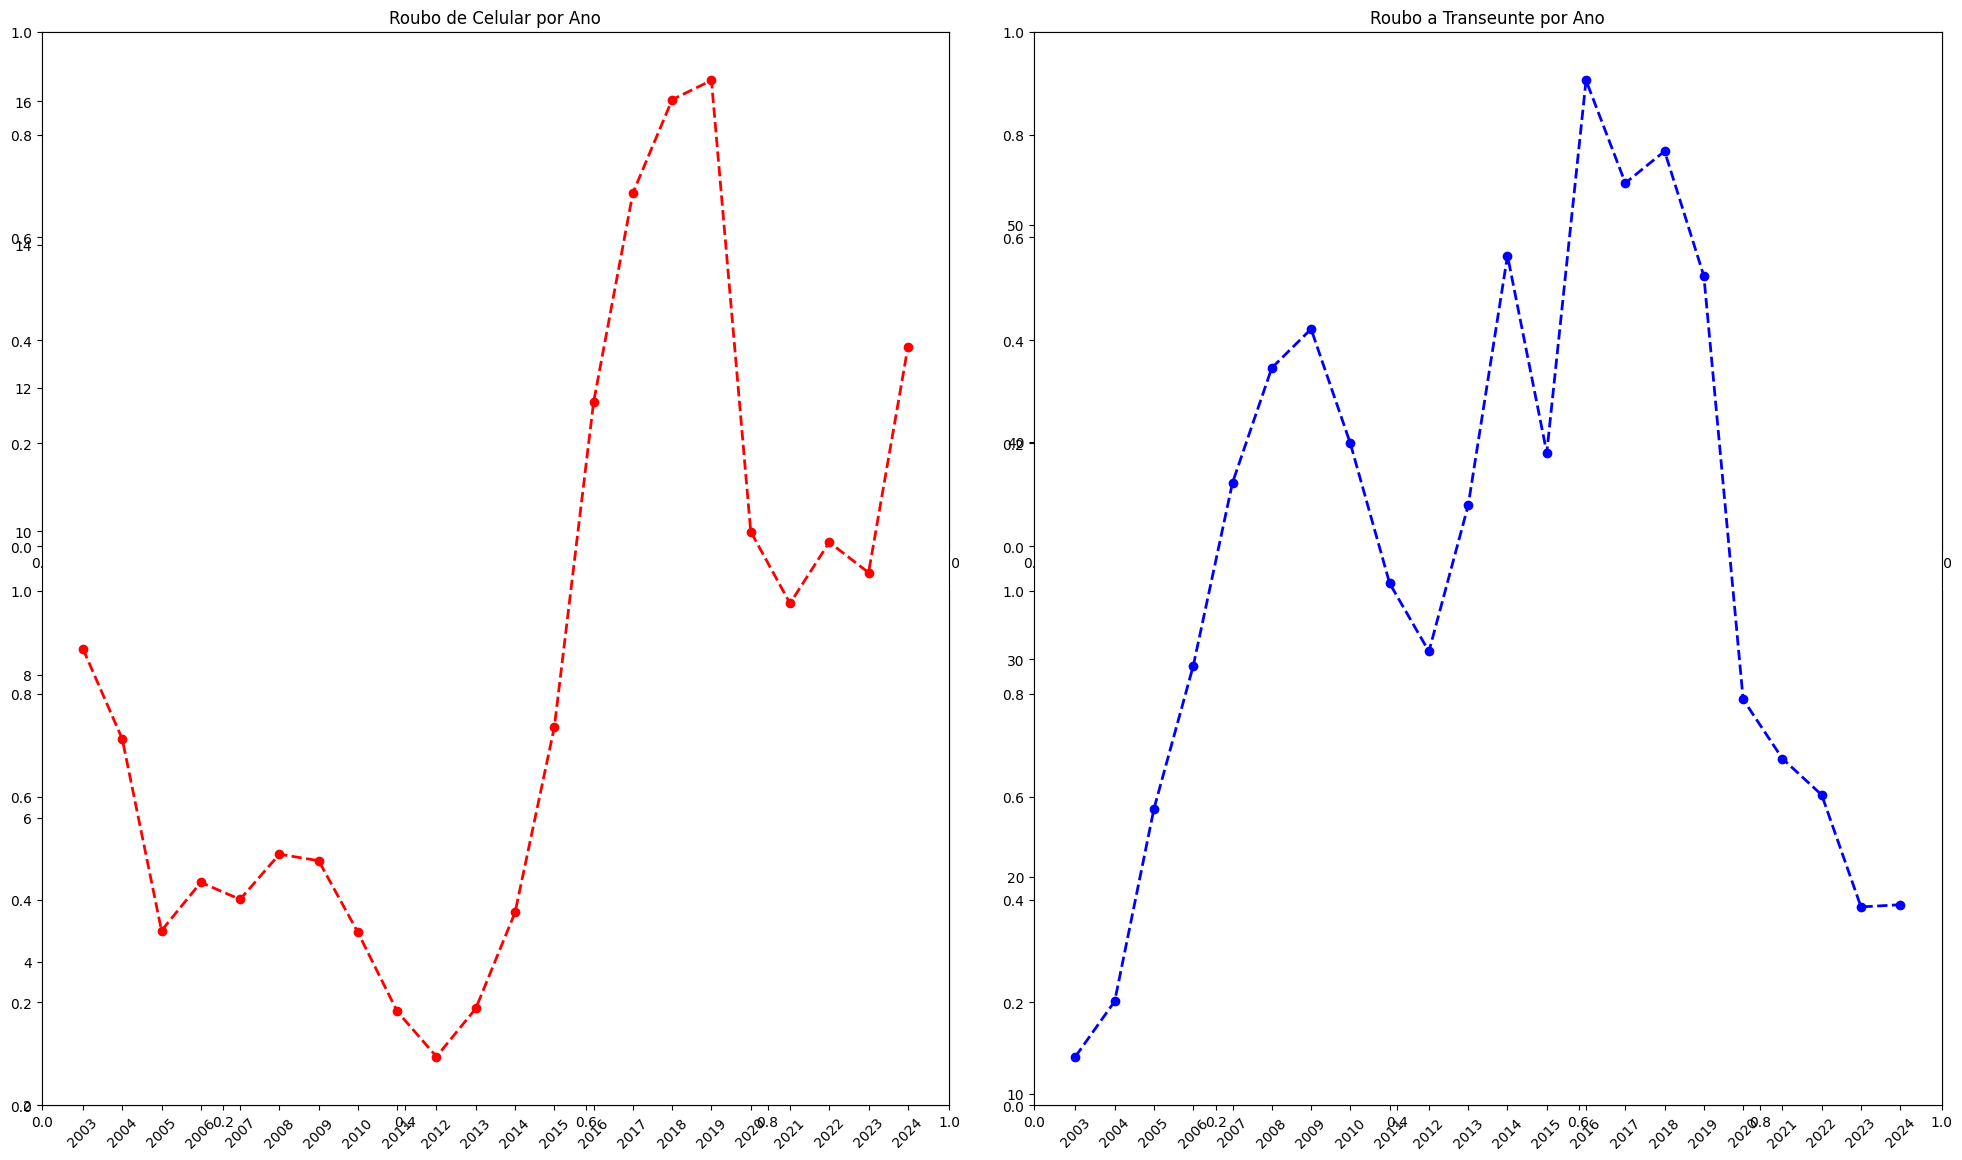

In [203]:
plt.subplots(2, 2, figsize=(20, 12))   
f_roubo_celular_ano = df_merge.groupby('ano')['roubo_celular'].mean().reset_index()
df_roubo_transeunte_ano = df_merge.groupby('ano')['roubo_transeunte'].mean().reset_index()

plt.subplot(1, 2, 1)
plt.plot(
        f_roubo_celular_ano['ano'].astype(str),
        f_roubo_celular_ano['roubo_celular'],
        marker='o',
        color='red',
        linestyle='--',
        linewidth=2
)
plt.xticks(rotation=45)
plt.title('Roubo de Celular por Ano')

plt.subplot(1, 2, 2)
plt.plot(
        df_roubo_transeunte_ano['ano'].astype(str),
        df_roubo_transeunte_ano['roubo_transeunte'],
        marker='o',
        color='blue',
        linestyle='--',
        linewidth=2
)
plt.xticks(rotation=45)
plt.title('Roubo a Transeunte por Ano')

plt.tight_layout()
plt.show()